In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
pd.set_option('display.max_columns', None)

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.shape

(6948, 202)

In [4]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,14.5691,5.7487,-7.2393,4.2840,30.7133,10.5350,16.2191,2.5791,2.4716,14.3831,13.4325,-5.1488,-0.4073,4.9306,5.9965,-0.3085,12.9041,-3.8766,16.8911,11.1920,10.5785,0.6764,7.8871,4.6667,3.8743,-5.2387,7.3746,11.5767,12.0446,11.6418,-7.0170,5.9226,-14.2136,16.0283,5.3253,12.9194,29.0460,-0.6940,5.1736,-0.7474,14.8322,11.2668,5.3822,2.0183,10.1166,16.1828,4.9590,2.0771,-0.2154,8.6748,9.5319,5.8056,22.4321,5.0109,-4.7010,21.6374,0.5663,5.1999,8.8600,43.1127,18.3816,-2.3440,23.4104,6.5199,12.1983,13.6468,13.8372,1.3675,2.9423,-4.5213,21.4669,9.3225,16.4597,7.9984,-1.7069,-21.4494,6.7806,11.0924,9.9913,14.8421,0.1812,8.9642,16.2572,2.1743,-3.4132,9.4763,13.3102,26.5376,1.4403,14.7100,6.0454,9.5426,17.1554,14.1104,24.3627,2.0323,6.7602,3.9141,-0.4851,2.5240,1.5093,2.5516,15.5752,-13.4221,7.2739,16.0094,9.7268,0.8897,0.7754,4.2218,12.0039,13.8571,-0.7338,-1.9245,15.4462,12.8287,0.3587,9.6508,6.5674,5.1726,3.1345,29.4547,31.4045,2.8279,15.6599,8.3307,-5.6011,19.0614,11.2663,8.6989,8.3694,11.5659,-16.4727,4.0288,17.9244,18.5177,10.7800,9.0056,16.6964,10.4838,1.6573,12.1749,-13.1324,17.6054,11.5423,15.4576,5.3133,3.6159,5.0384,6.6760,12.6644,2.7004,-0.6975,9.5981,5.4879,-4.7645,-8.4254,20.8773,3.1531,18.5618,7.7423,-10.1245,13.7241,-3.5189,1.7202,-8.4051,9.0164,3.0657,14.3691,25.8398,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,13.7003,13.8275,-15.5849,7.8000,28.5708,3.4287,2.7407,8.5524,3.3716,6.9779,13.8910,-11.7684,-2.5586,5.0464,0.5481,-9.2987,7.8755,1.2859,19.3710,11.3702,0.7399,2.7995,5.8434,10.8160,3.6783,-11.1147,1.8730,9.8775,11.7842,1.2444,-47.3797,7.3718,0.1948,34.4014,25.7037,11.8343,13.2256,-4.1083,6.6885,-8.0946,18.5995,19.3219,7.0118,1.9210,8.8682,8.0109,-7.2417,1.7944,-1.3147,8.1042,1.5365,5.4007,7.9344,5.0220,2.2302,40.5632,0.5134,3.1701,20.1068,7.7841,7.0529,3.2709,23.4822,5.5075,13.7814,2.5462,18.1782,0.3683,-4.8210,-5.4850,13.7867,-13.5901,11.0993,7.9022,12.2301,0.4768,6.8852,8.0905,10.9631,11.7569,-1.2722,24.7876,26.6881,1.8944,0.6939,-13.6950,8.4068,35.4734,1.7093,15.1866,2.6227,7.3412,32.0888,13.9550,13.0858,6.6203,7.1051,5.3523,8.5426,3.6159,4.1569,3.0454,7.8522,-11.5100,7.5109,31.5899,9.5018,8.2736,10.1633,0.1225,12.5942,14.5697

In [5]:
df.tail()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
6943,train_6943,0,7.4626,0.3237,10.9062,7.3976,10.4262,1.5827,3.7626,10.1179,-2.2389,8.4139,-9.7624,-13.1630,13.9200,1.0925,7.5306,14.4865,12.3732,-1.7139,8.1250,19.0182,20.1442,9.6740,8.0241,3.2570,9.3116,13.8373,-4.0182,-2.0376,5.7459,2.3912,-4.0165,11.0008,-3.0811,17.4875,11.4177,7.0072,-3.9173,4.0534,10.1294,-3.8446,-6.9694,1.9739,10.4349,12.1684,3.2602,-23.7188,15.9083,11.0986,10.2974,16.7531,11.6008,21.9467,-4.6904,6.6114,-4.2807,9.0452,11.7055,5.5846,16.3213,8.3407,13.1856,-29.2293,0.9656,2.2474,3.6808,-3.7228,5.0762,16.5149,5.0115,-0.9695,20.9113,0.9127,-2.9874,24.5876,39.9878,13.9184,-5.7810,21.1719,7.3348,15.0691,13.4258,15.2391,-7.1021,0.5744,-0.8329,20.2747,-6.7826,4.8788,6.6390,2.9552,3.7330,6.9714,6.5721,11.0518,8.0519,0.7634,2.6165,17.2120,1.8630,-4.5309,-2.4418,16.9874,17.3125,1.7791,9.5318,3.6573,10.0599,17.7982,14.3098,27.4343,5.6393,6.8350,2.6294,14.9926,4.4229,1.4544,1.3002,14.8763,-8.2416,-0.1549,23.8013,9.1247,2.6430,14.4771,4.7451,12.1866,14.0633,-3.8864,-4.4372,10.0279,10.8054,0.6431,8.4941,7.1437,-2.4220,-16.6477,10.0956,12.3563,10.0256,22.1859,-1.8569,-0.2006,7.5882,8.5930,8.1273,2.6584,9.8647,-12.6655,3.9947,-0.9791,18.7789,6.0800,12.5014,17.1813,7.0588,-0.6875,11.5898,-2.2808,16.0401,5.9354,3.3254,5.9060,5.1583,1.2842,2.8003,22.7209,3.3854,-15.5835,3.7669,5.7608,1.7224,-7.0048,23.6867,1.8619,26.6514,7.0145,-14.0204,14.2182,-8.8889,4.4180,-7.5240,10.5638,3.0085,13.9588,19.6106,3.3957,14.0111,-26.5227,19.9725,0.4326,7.4093,4.7120,4.1863,5.1907,15.0648,-0.7623,-2.1043,9.0039,22.5225,-6.7011
6944,train_6944,0,18.2507,5.5285,14.5660,8.1469,10.4907,6.0126,6.1463,15.1119,-5.8546,4.6702,2.7728,-7.3310,13.7325,1.7230,10.9462,14.3053,5.9550,-6.5194,21.0972,16.6214,23.5393,6.2192,7.8607,2.7395,5.6381,13.8190,-13.9531,1.0957,6.8025,4.9394,-4.9205,9.0308,1.3940,18.4371,11.6631,8.8393,-1.3651,6.0879,8.8372,-1.7890,-19.6692,15.3633,10.6756,10.8873,6.9873,-21.7496,8.7160,-18.6597,20.6699,29.5407,12.7425,20.7204,-2.1490,5.4610,8.7830,15.1059,21.9919,5.3209,6.7744,8.6086,11.0656,-3.9769,-0.6231,0.0184,6.5920,-3.4842,5.7493,0.7204,5.0306,2.5439,22.0033,0.5534,3.3861,12.3390,15.1922,11.4071,-1.7561,17.7780,7.0386,15.3806,12.7071,13.1174,-16.0999,-3.0412,-0.0087,15.9068,6.4565,4.2402,5.0208,6.7518,-1.7151,7.2603,20.7011,9.8646,8.2874,0.6875,10.9976,12.6394,1.0310,0.9609,2.9945,5.4653,9.4553,1.2193,9.7470,2.7281,9.6391,10.7889,14.4178,19.0861,6.4134,6.2401,2.6787,8.7148,3.2066,3.2505,3.3218,37.5915,-1.9954,6.5825,21.2025,12.1031,-11.0299,8.9734

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6948 entries, 0 to 6947
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 10.7+ MB


In [7]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6948.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.00000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000,6947.000000
mean,0.098014,10.693629,-1.683484,10.691057,6.810956,11.078582,-5.041017,5.394692,16.

In [8]:
df.isnull().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,1
var_196,1
var_197,1
var_198,1


In [9]:
df.duplicated().sum()

np.int64(0)

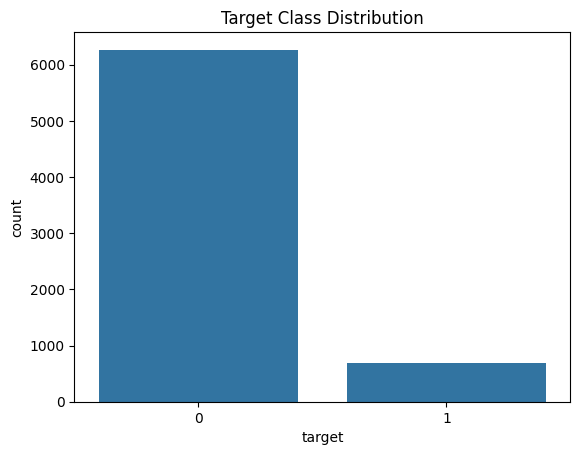

target
0    6267
1     681
Name: count, dtype: int64


In [10]:
sns.countplot(x='target', data=df)
plt.title("Target Class Distribution")
plt.show()

print(df['target'].value_counts())

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [12]:
x=df.drop(columns=["ID_code","target"])
y=df["target"]

In [13]:

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42, stratify=y, test_size=0.2)

In [14]:

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [15]:

logreg=LogisticRegression(max_iter=1000,
    random_state=42)
logreg.fit(x_train_scaled,y_train)
y_pred=logreg.predict(x_test_scaled)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

Accuracy : 0.9136690647482014
Precision: 0.6481481481481481
Recall   : 0.25735294117647056
F1 Score : 0.3684210526315789


In [16]:
C_values = [0.01,0.05, 0.1, 1, 10, 100]

results = []

for c in C_values:

    model = LogisticRegression(
        C=c,
        max_iter=1000,
        random_state=42
    )

    model.fit(x_train_scaled, y_train)

    pred = model.predict(x_test_scaled)

    prob = model.predict_proba(x_test_scaled)[:,1]

    results.append({
        "C": c,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

display(results_df)

,C,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.01,0.914388,0.793103,0.169118,0.278788,0.858213
1,0.05,0.916547,0.708333,0.250000,0.369565,0.854759
2,0.10,0.915108,0.680000,0.250000,0.365591,0.854137
3,1.00,0.913669,0.648148,0.257353,0.368421,0.853492
4,10.00,0.913669,0.648148,0.257353,0.368421,0.853475
5,100.00,0.913669,0.648148,0.257353,0.368421,0.853481


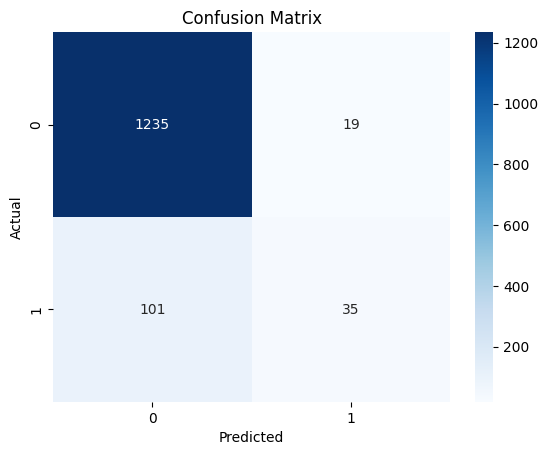

In [17]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

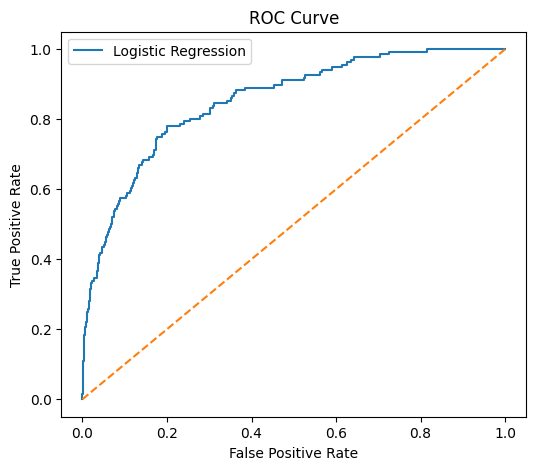

In [18]:
from sklearn.metrics import roc_curve

y_prob = logreg.predict_proba(x_test_scaled)[:,1]

fpr,tpr,threshold = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Logistic Regression")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [19]:
roc_auc_score(y_test,y_prob)

np.float64(0.8534923538793507)

## Effect of Feature Scaling

Logistic Regression is sensitive to the scale or range of input sample of a feature because it optimizes its parameters using gradient-based optimization.

StandardScaler is used to transform all numerical features to a common scale,helps in improving optimization stability, reducing convergence time, and preventsfeatures with larger values from dominating the learning process.

## Effect of Regularization

The regularization parameter (C) controls the strength of regularization in Logistic Regression.

Smaller values of C apply stronger regularization, reducing model complexity and helping to prevent overfitting. Larger values of C reduce the effect of regularization, allowing the model to fit the training data more closely.

From the experiments, different values of C produced different trade-offs between Accuracy, Precision, Recall, and ROC-AUC.

## Class Imbalance

The target variable is imbalanced, total count of class 0 is much more than class 1.

Due to this imbalance, Accuracy alone is not sufficient for evaluating the model. Therefore,Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix were also used to assess classification performance.

The relatively lower Recall indicates that the model still misses a number of positive class instances.

## Model Comparison

Different values of the regularization parameter (C) were tested.

Smaller values of C produced stronger regularization, whereas larger values allowed the model to fit the training data more closely.

Based on the evaluation metrics, C = 0.01 achieved the best balance between Accuracy, Precision, Recall, F1-score, and ROC-AUC for this dataset.

# Conclusion

We successfully preprocessed Santander Customer Transaction Prediction by handling missing values, applying feature scaling, and splitting the dataset into training and testing sets.

we trained Logistic Regression model and evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, the Confusion Matrix, and the ROC Curve.

Different values of the regularization parameter (C) were tested to study the effect of regularization.

Although the dataset is imbalanced, the model achieved good overall performance. The ROC Curve and ROC-AUC score indicate that the classifier performs better than random guessing, while the comparison of different C values demonstrates the impact of regularization on model performance.